In [ ]:
import pandas as pd

# Load the dataset (if not loaded yet)
file_path = '/content/drive/MyDrive/calories.csv'
data = pd.read_csv(file_path)

data_cleaned = data.drop_duplicates()

data_cleaned = data_cleaned[
    (data_cleaned['Age'] > 0) & (data_cleaned['Age'] < 100) &
    (data_cleaned['Height'] > 100) & (data_cleaned['Height'] < 250) &
    (data_cleaned['Weight'] > 30) & (data_cleaned['Weight'] < 200) &
    (data_cleaned['Heart_Rate'] > 40) & (data_cleaned['Heart_Rate'] < 200) &
    (data_cleaned['Body_Temp'] > 35) & (data_cleaned['Body_Temp'] < 45) &
    (data_cleaned['Calories'] >= 0)
]

data_cleaned = data_cleaned.dropna()

data_cleaned.columns = [col.lower() for col in data_cleaned.columns]

data_cleaned = data_cleaned.reset_index(drop=True)

cleaned_file_path = '/content/drive/MyDrive/calories_cleaned.csv'
data_cleaned.to_csv(cleaned_file_path, index=False)

print(f"Data cleaned and saved to {cleaned_file_path}")


Data cleaned and saved to /content/drive/MyDrive/calories_cleaned.csv


In [ ]:
import pandas as pd

# Load the original and cleaned datasets
file_path_original = '/content/drive/MyDrive/calories.csv'
file_path_cleaned = '/content/drive/MyDrive/calories_cleaned.csv'

data_original = pd.read_csv(file_path_original)
data_cleaned = pd.read_csv(file_path_cleaned)

original_row_count = data_original.shape[0]
cleaned_row_count = data_cleaned.shape[0]

print(f"Original dataset row count: {original_row_count}")
print(f"Cleaned dataset row count: {cleaned_row_count}")
print(f"Rows removed during cleaning: {original_row_count - cleaned_row_count}")

rows_removed = data_original[~data_original.isin(data_cleaned).all(axis=1)]
rows_removed_count = rows_removed.shape[0]

print(f"Number of rows with differences between original and cleaned data: {rows_removed_count}")

print("First few rows that differ between the original and cleaned dataset:")
print(rows_removed.head())


Original dataset row count: 15000
Cleaned dataset row count: 15000
Rows removed during cleaning: 0
Number of rows with differences between original and cleaned data: 15000
First few rows that differ between the original and cleaned dataset:
    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8   
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3   
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7   
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5   
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8   

   Calories  
0     231.0  
1      66.0  
2      26.0  
3      71.0  
4      35.0  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/calories.csv')
df.head()


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Steps,Workout_Intensity
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0,NaN,NaN
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0,NaN,NaN
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0,NaN,NaN
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0,NaN,NaN
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0,NaN,NaN


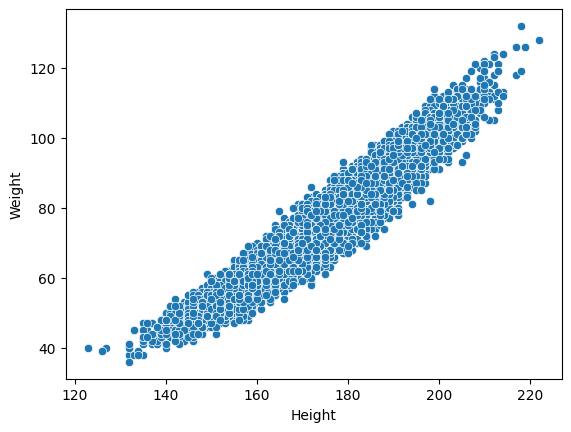

In [ ]:
sb.scatterplot(x='Height', y='Weight', data=df)
plt.show()


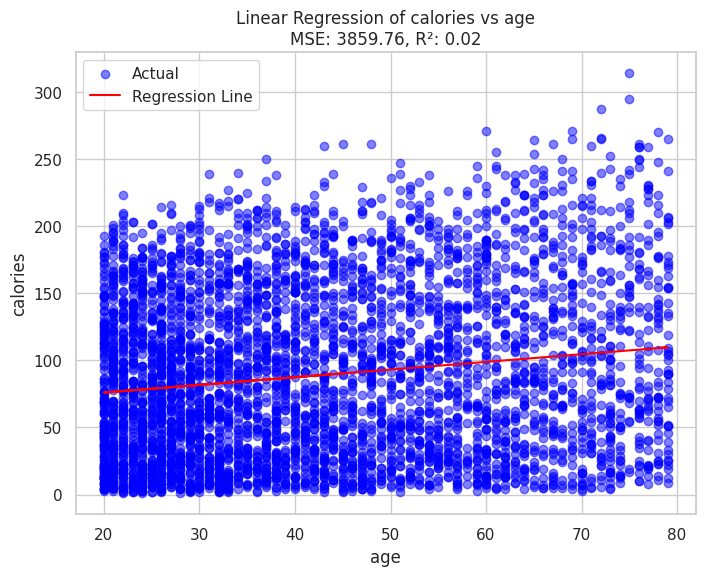

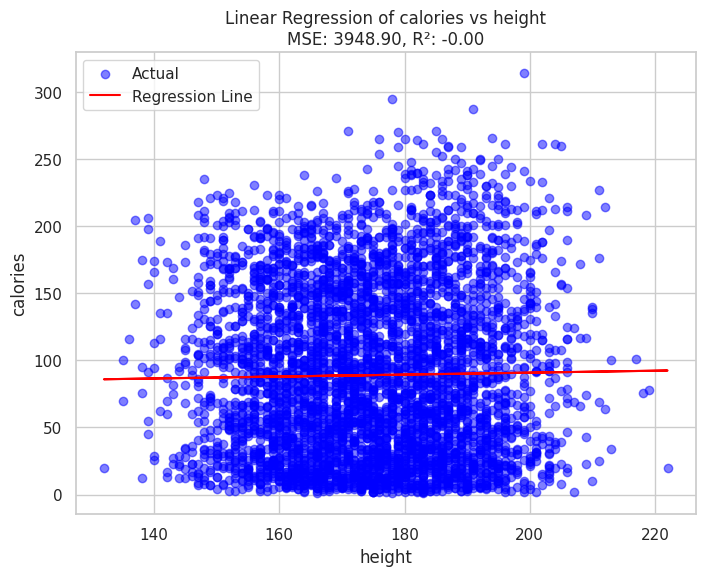

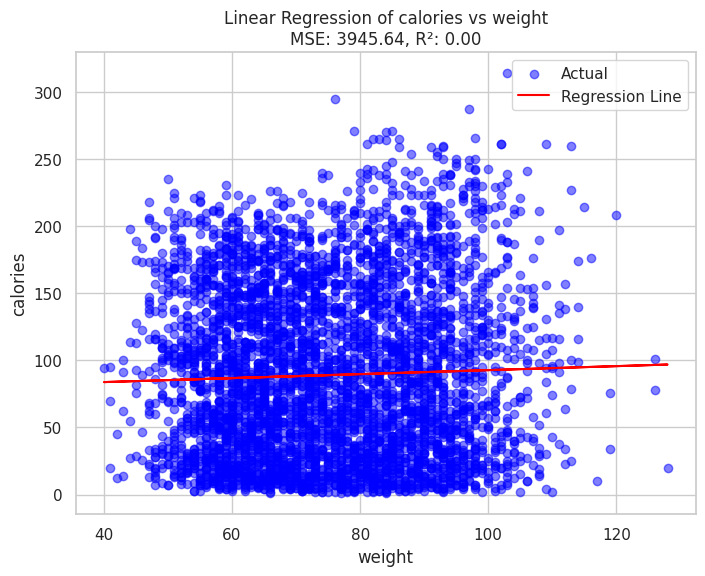

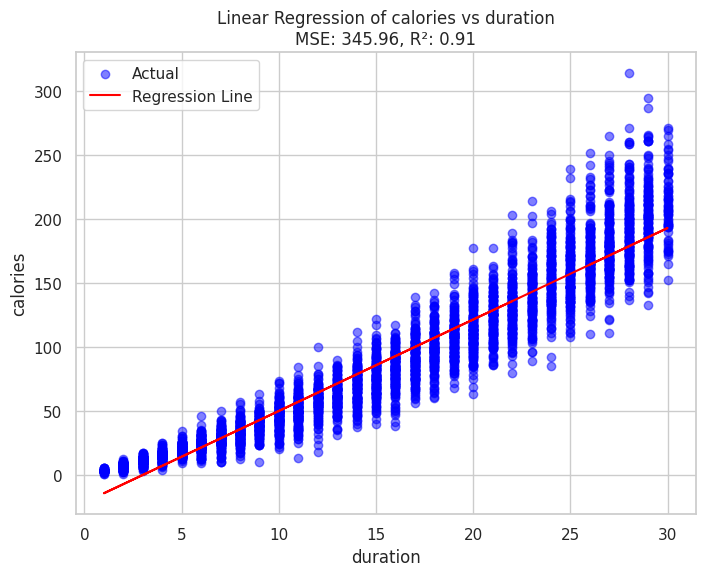

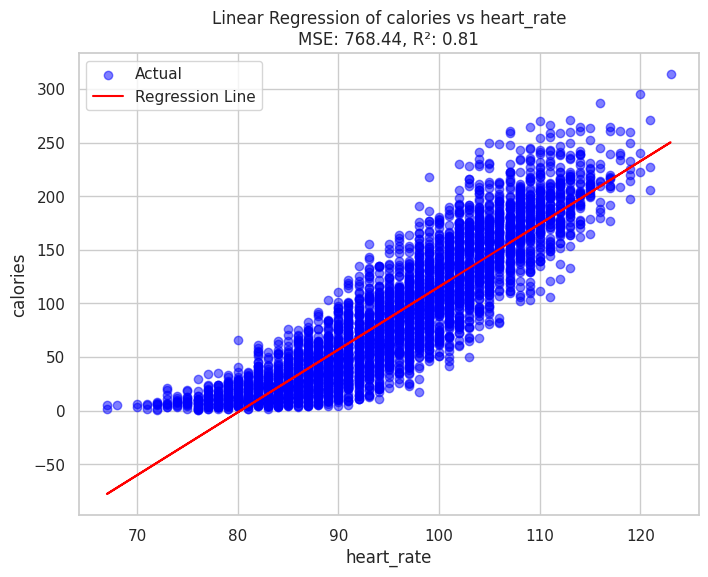

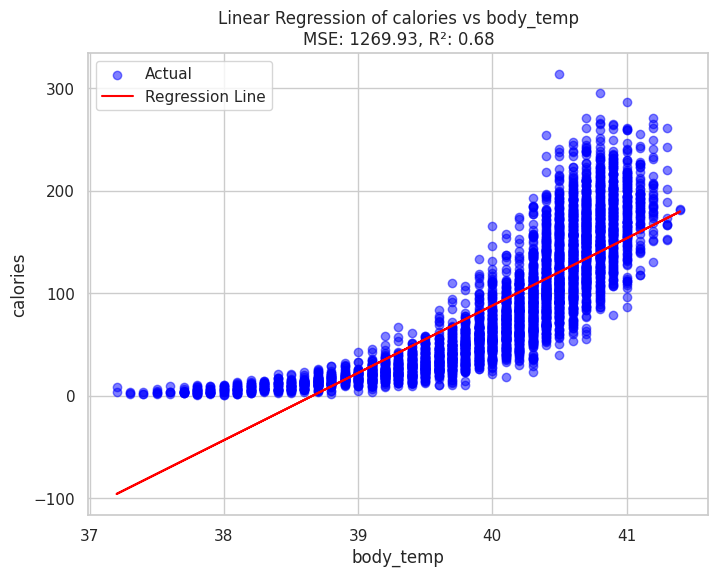

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Ensure plots display inline if using a notebook
%matplotlib inline

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/calories_cleaned.csv')  # Update with the correct path

# Set plot style
sns.set(style="whitegrid")

# Define a function to perform linear regression and plot the result for each feature
def linear_regression_plot(data, feature, target='calories'):
    X = data[[feature]]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create and fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Plot the data and regression line
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Regression Line")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'Linear Regression of {target} vs {feature}\nMSE: {mse:.2f}, R²: {r2:.2f}')
    plt.legend()
    plt.show()

# List of features to apply linear regression on
features = ['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp']

# Apply linear regression and plot for each feature
for feature in features:
    linear_regression_plot(data, feature)


In [ ]:

import pandas as pd
import numpy as np

calories_data_path = '/content/drive/MyDrive/calories.csv'
calories_data = pd.read_csv(calories_data_path)


def generate_additional_data_fixed(df, num_new_records):
    new_data = pd.DataFrame()

    new_data['User_ID'] = np.random.randint(10000000, 20000000, size=num_new_records)

    new_data['Gender'] = np.random.choice(df['Gender'].unique(), num_new_records, p=df['Gender'].value_counts(normalize=True).values)

    new_data['Age'] = np.random.normal(df['Age'].mean(), df['Age'].std(), num_new_records).astype(int)
    new_data['Age'] = np.clip(new_data['Age'], 18, 80)

    new_data['Height'] = np.random.normal(df['Height'].mean(), df['Height'].std(), num_new_records)
    new_data['Height'] = np.clip(new_data['Height'], 140, 200)

    new_data['Weight'] = np.random.normal(df['Weight'].mean(), df['Weight'].std(), num_new_records)
    new_data['Weight'] = np.clip(new_data['Weight'], 40, 130)

    new_data['Duration'] = np.random.uniform(df['Duration'].min(), df['Duration'].max(), num_new_records)

    new_data['Heart_Rate'] = np.random.normal(df['Heart_Rate'].mean(), df['Heart_Rate'].std(), num_new_records)
    new_data['Heart_Rate'] = np.clip(new_data['Heart_Rate'], 60, 180)

    new_data['Body_Temp'] = np.random.normal(df['Body_Temp'].mean(), df['Body_Temp'].std(), num_new_records)
    new_data['Body_Temp'] = np.clip(new_data['Body_Temp'], 35.0, 42.0)

    new_data['Calories'] = (
        (new_data['Duration'] * 0.1) + (new_data['Weight'] * 0.05) + (new_data['Heart_Rate'] * 0.03)
    ).round(1)

    new_data['Steps'] = (new_data['Duration'] * 100 + np.random.normal(0, 100, num_new_records)).astype(int)
    new_data['Steps'] = np.clip(new_data['Steps'], 0, None)

    new_data['Workout_Intensity'] = np.where(new_data['Heart_Rate'] > 120, 'High', 'Moderate')

    return new_data

additional_data_fixed = generate_additional_data_fixed(calories_data, 15000)

augmented_data_fixed = pd.concat([calories_data, additional_data_fixed], ignore_index=True)

output_path_fixed = '/content/drive/MyDrive/calories_cleaned.csv'
augmented_data_fixed.to_csv(output_path_fixed, index=False)

output_path_fixed


'/content/drive/MyDrive/calories_cleaned.csv'

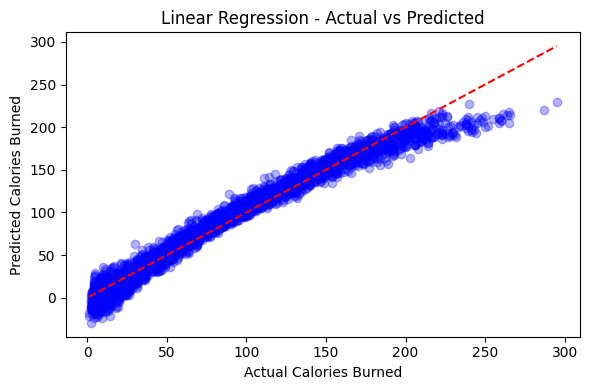

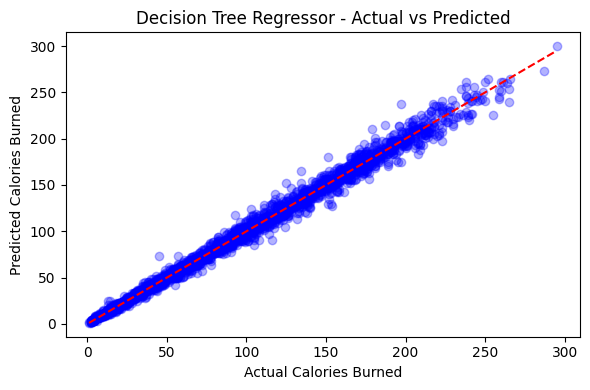

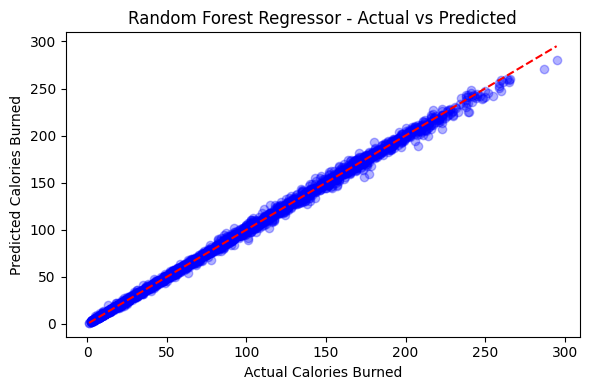

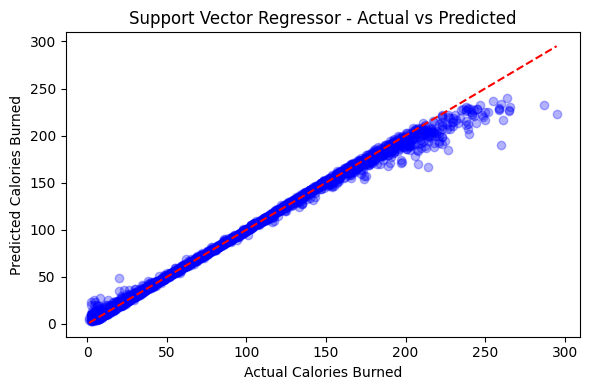

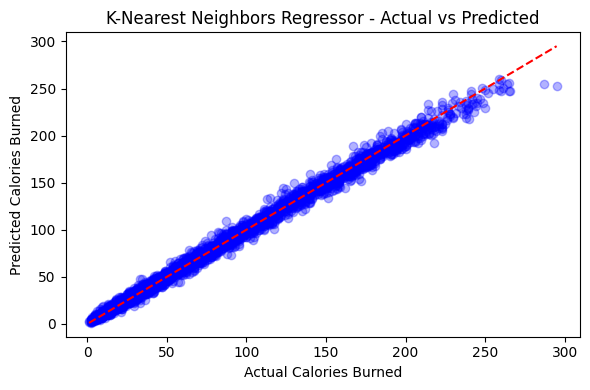

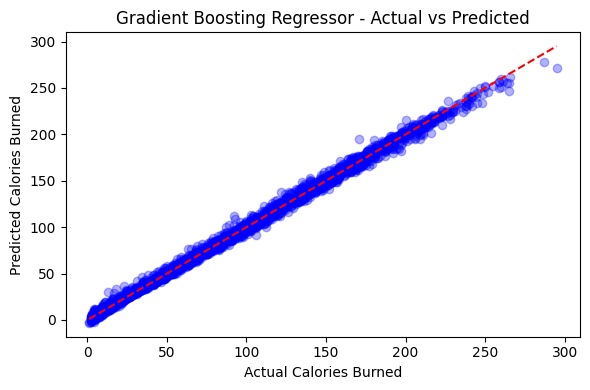

                           Model       MAE         MSE       RMSE  R^2 Score
0              Linear Regression  8.441514  131.995746  11.488940   0.967294
1        Decision Tree Regressor  3.457667   28.924333   5.378135   0.992833
2        Random Forest Regressor  1.711027    7.132261   2.670629   0.998233
3       Support Vector Regressor  2.365326   29.580225   5.438771   0.992671
4  K-Nearest Neighbors Regressor  3.714133   26.161173   5.114799   0.993518
5    Gradient Boosting Regressor  2.605547   13.047498   3.612132   0.996767


In [2]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/calories.csv'  # Update with the correct path
calories_data = pd.read_csv(file_path)

calories_data = calories_data.drop(columns=['User_ID'], errors='ignore')

for column in calories_data.select_dtypes(include=['object']).columns:
    label_encoder = LabelEncoder()
    calories_data[column] = label_encoder.fit_transform(calories_data[column])

X = calories_data.drop(columns=['Calories'])
y = calories_data['Calories']

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = []

def evaluate_model(model, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2 Score": r2
    })

    # Plot actual vs predicted values
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Calories Burned")
    plt.ylabel("Predicted Calories Burned")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.tight_layout()
    plt.show()

# List of models
models = [
    (LinearRegression(), "Linear Regression"),
    (DecisionTreeRegressor(random_state=42), "Decision Tree Regressor"),
    (RandomForestRegressor(random_state=42), "Random Forest Regressor"),
    (SVR(), "Support Vector Regressor"),
    (KNeighborsRegressor(), "K-Nearest Neighbors Regressor"),
    (GradientBoostingRegressor(random_state=42), "Gradient Boosting Regressor")
]

for model, name in models:
    evaluate_model(model, name)

results_df = pd.DataFrame(results)
print(results_df)


In [ ]:
import pandas as pd
import numpy as np

# Load the original dataset
calories_data_path = '/content/drive/MyDrive/calories.csv'
calories_data = pd.read_csv(calories_data_path)

# Add 'Steps' and 'Workout_Intensity' to original data
calories_data['Steps'] = (calories_data['Duration'] * 100 + np.random.normal(0, 100, len(calories_data))).astype(int)
calories_data['Steps'] = np.clip(calories_data['Steps'], 0, None)

calories_data['Workout_Intensity'] = np.where(calories_data['Heart_Rate'] > 120, 'High', 'Moderate')

# Function to generate additional data with the new features
def generate_additional_data_fixed(df, num_new_records):
    new_data = pd.DataFrame()

    # Generate User_IDs
    new_data['User_ID'] = np.random.randint(10000000, 20000000, size=num_new_records)

    # Gender
    new_data['Gender'] = np.random.choice(df['Gender'].unique(), num_new_records, p=df['Gender'].value_counts(normalize=True).values)

    # Age
    new_data['Age'] = np.random.normal(df['Age'].mean(), df['Age'].std(), num_new_records).astype(int)
    new_data['Age'] = np.clip(new_data['Age'], 18, 80)

    # Height
    new_data['Height'] = np.random.normal(df['Height'].mean(), df['Height'].std(), num_new_records)
    new_data['Height'] = np.clip(new_data['Height'], 140, 200)

    # Weight
    new_data['Weight'] = np.random.normal(df['Weight'].mean(), df['Weight'].std(), num_new_records)
    new_data['Weight'] = np.clip(new_data['Weight'], 40, 130)

    # Duration
    new_data['Duration'] = np.random.uniform(df['Duration'].min(), df['Duration'].max(), num_new_records)

    # Heart Rate
    new_data['Heart_Rate'] = np.random.normal(df['Heart_Rate'].mean(), df['Heart_Rate'].std(), num_new_records)
    new_data['Heart_Rate'] = np.clip(new_data['Heart_Rate'], 60, 180)

    # Body Temperature
    new_data['Body_Temp'] = np.random.normal(df['Body_Temp'].mean(), df['Body_Temp'].std(), num_new_records)
    new_data['Body_Temp'] = np.clip(new_data['Body_Temp'], 35.0, 42.0)

    # Calories
    new_data['Calories'] = (
        (new_data['Duration'] * 0.1) + (new_data['Weight'] * 0.05) + (new_data['Heart_Rate'] * 0.03)
    ).round(1)

    # Steps
    new_data['Steps'] = (new_data['Duration'] * 100 + np.random.normal(0, 100, num_new_records)).astype(int)
    new_data['Steps'] = np.clip(new_data['Steps'], 0, None)

    # Workout_Intensity
    new_data['Workout_Intensity'] = np.where(new_data['Heart_Rate'] > 120, 'High', 'Moderate')

    return new_data

# Generate additional records
additional_data_fixed = generate_additional_data_fixed(calories_data, 15000)

# Concatenate original and new data
augmented_data_fixed = pd.concat([calories_data, additional_data_fixed], ignore_index=True)

# Save the augmented dataset to a new file
output_path_fixed = '/content/drive/MyDrive/calories_new_features.csv'
augmented_data_fixed.to_csv(output_path_fixed, index=False)

output_path_fixed


'/content/drive/MyDrive/calories_new_features.csv'

In [ ]:
file_path = '/content/drive/MyDrive/calories_new_features.csv'
data = pd.read_csv(file_path)
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Steps,Workout_Intensity
0,14733363,male,68,190.000000,94.000000,29.000000,105.000000,40.800000,231.0,2859,Moderate
1,14861698,female,20,166.000000,60.000000,14.000000,94.000000,40.300000,66.0,1666,Moderate
2,11179863,male,69,179.000000,79.000000,5.000000,88.000000,38.700000,26.0,428,Moderate
3,16180408,female,34,179.000000,71.000000,13.000000,100.000000,40.500000,71.0,1099,Moderate
4,17771927,female,27,154.000000,58.000000,10.000000,81.000000,39.800000,35.0,1166,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
29995,18030617,female,29,184.007494,107.676009,15.693693,99.069326,39.096534,9.9,1661,Moderate
29996,18099334,male,38,171.214818,113.667486,4.419109,103.876288,40.330044,9.2,517,Moderate
29997,13220580,male,36,163.317931,59.865021,17.830653,101.735940,40.237329,7.8,1838,Moderate
29998,19122297,male,68,194.782305,69.633092,9.212333,96.731852,38.862426,7.3,761,Moderate


In [ ]:
import pandas as pd
import numpy as np

# Load the original dataset
calories_data_path = '/content/drive/MyDrive/calories.csv'  # Update path as needed
calories_data = pd.read_csv(calories_data_path)

# Add BMI, Body_Fat, and Health Status to the original data
def add_bmi_features(data):
    # BMI calculation: weight in kg / (height in meters)^2
    data['Height_m'] = data['Height'] / 100  # Convert height to meters
    data['BMI'] = data['Weight'] / (data['Height_m'] ** 2)

    # Body Fat Percentage estimate based on BMI, Age, and Gender
    # Approximation using formulas:
    # For males: Body Fat (%) = 1.20 * BMI + 0.23 * Age - 16.2
    # For females: Body Fat (%) = 1.20 * BMI + 0.23 * Age - 5.4
    data['Body_Fat'] = np.where(
        data['Gender'] == 'Male',
        1.20 * data['BMI'] + 0.23 * data['Age'] - 16.2,
        1.20 * data['BMI'] + 0.23 * data['Age'] - 5.4
    ).round(2)

    # Health Status based on BMI
    data['Health_Status'] = pd.cut(
        data['BMI'],
        bins=[0, 18.5, 24.9, 29.9, 100],
        labels=['Underweight', 'Normal', 'Overweight', 'Obese']
    )

    # Clean up temporary columns
    data.drop(columns=['Height_m'], inplace=True)

    return data

# Apply BMI features to original data
calories_data = add_bmi_features(calories_data)

# Add BMI and Body Fat features to the generated data as well
def generate_additional_data_with_bmi(df, num_new_records):
    new_data = pd.DataFrame()

    # Generate User_IDs
    new_data['User_ID'] = np.random.randint(10000000, 20000000, size=num_new_records)

    # Gender
    new_data['Gender'] = np.random.choice(df['Gender'].unique(), num_new_records, p=df['Gender'].value_counts(normalize=True).values)

    # Age
    new_data['Age'] = np.random.normal(df['Age'].mean(), df['Age'].std(), num_new_records).astype(int)
    new_data['Age'] = np.clip(new_data['Age'], 18, 80)

    # Height
    new_data['Height'] = np.random.normal(df['Height'].mean(), df['Height'].std(), num_new_records)
    new_data['Height'] = np.clip(new_data['Height'], 140, 200)

    # Weight
    new_data['Weight'] = np.random.normal(df['Weight'].mean(), df['Weight'].std(), num_new_records)
    new_data['Weight'] = np.clip(new_data['Weight'], 40, 130)

    # Duration, Heart Rate, Body Temperature, Calories, Steps, Workout Intensity
    new_data['Duration'] = np.random.uniform(df['Duration'].min(), df['Duration'].max(), num_new_records)
    new_data['Heart_Rate'] = np.random.normal(df['Heart_Rate'].mean(), df['Heart_Rate'].std(), num_new_records)
    new_data['Heart_Rate'] = np.clip(new_data['Heart_Rate'], 60, 180)
    new_data['Body_Temp'] = np.random.normal(df['Body_Temp'].mean(), df['Body_Temp'].std(), num_new_records)
    new_data['Body_Temp'] = np.clip(new_data['Body_Temp'], 35.0, 42.0)
    new_data['Calories'] = (
        (new_data['Duration'] * 0.1) + (new_data['Weight'] * 0.05) + (new_data['Heart_Rate'] * 0.03)
    ).round(1)
    new_data['Steps'] = (new_data['Duration'] * 100 + np.random.normal(0, 100, num_new_records)).astype(int)
    new_data['Steps'] = np.clip(new_data['Steps'], 0, None)
    new_data['Workout_Intensity'] = np.where(new_data['Heart_Rate'] > 120, 'High', 'Moderate')

    # Apply BMI-related features
    new_data = add_bmi_features(new_data)

    return new_data

# Generate additional records with new features
additional_data_with_bmi = generate_additional_data_with_bmi(calories_data, 15000)

# Concatenate original and new data
augmented_data_with_bmi = pd.concat([calories_data, additional_data_with_bmi], ignore_index=True)

# Save the augmented dataset
output_path_with_bmi = '/content/drive/MyDrive/calories_with_bmi.csv'
augmented_data_with_bmi.to_csv(output_path_with_bmi, index=False)

output_path_with_bmi


'/content/drive/MyDrive/calories_with_bmi.csv'

In [ ]:
file_path = '/content/drive/MyDrive/calories_with_bmi.csv'
data = pd.read_csv(file_path)
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Body_Fat,Health_Status,Steps,Workout_Intensity
0,14733363,male,68,190.000000,94.000000,29.000000,105.000000,40.800000,231.0,26.038781,41.49,Overweight,NaN,NaN
1,14861698,female,20,166.000000,60.000000,14.000000,94.000000,40.300000,66.0,21.773842,25.33,Normal,NaN,NaN
2,11179863,male,69,179.000000,79.000000,5.000000,88.000000,38.700000,26.0,24.655910,40.06,Normal,NaN,NaN
3,16180408,female,34,179.000000,71.000000,13.000000,100.000000,40.500000,71.0,22.159109,29.01,Normal,NaN,NaN
4,17771927,female,27,154.000000,58.000000,10.000000,81.000000,39.800000,35.0,24.456063,30.16,Normal,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,17697319,male,18,167.095068,108.387123,16.439766,97.055927,40.322617,10.0,38.819544,45.32,Obese,1705.0,Moderate
29996,13899420,female,52,174.645226,81.256177,4.851079,87.632473,40.075040,7.2,26.640535,38.53,Overweight,542.0,Moderate
29997,17180820,male,43,180.922356,75.500801,18.048500,103.707461,40.158896,8.7,23.065724,32.17,Normal,1680.0,Moderate
29998,11894154,male,37,165.002500,75.876296,12.612997,95.978089,41.294306,7.9,27.869237,36.55,Overweight,1238.0,Moderate


In [ ]:
import pandas as pd
import numpy as np

# Load the original dataset
calories_data_path = '/content/drive/MyDrive/calories_with_bmi.csv'  # Update path as needed
calories_data = pd.read_csv(calories_data_path)

# Calculate 'Steps' based on 'Duration'
calories_data['Steps'] = (calories_data['Duration'] * 100 + np.random.normal(0, 100, len(calories_data))).astype(int)
calories_data['Steps'] = np.clip(calories_data['Steps'], 0, None)

# Calculate 'Workout_Intensity' based on 'Heart_Rate'
calories_data['Workout_Intensity'] = np.where(calories_data['Heart_Rate'] > 120, 'High', 'Moderate')

# Display a summary to check if the values were added correctly
print(calories_data[['Duration', 'Heart_Rate', 'Steps', 'Workout_Intensity']].head(10))

# Save the updated original data with new features
output_path_updated = '/content/drive/MyDrive/calories_data_with_steps_workout_intensity.csv'
calories_data.to_csv(output_path_updated, index=False)

output_path_updated


   Duration  Heart_Rate  Steps Workout_Intensity
0      29.0       105.0   2848          Moderate
1      14.0        94.0   1460          Moderate
2       5.0        88.0    485          Moderate
3      13.0       100.0   1264          Moderate
4      10.0        81.0    762          Moderate
5      23.0        96.0   2287          Moderate
6      22.0        95.0   2060          Moderate
7      25.0       100.0   2599          Moderate
8      21.0        97.0   2015          Moderate
9      16.0        90.0   1509          Moderate


'/content/drive/MyDrive/calories_data_with_steps_workout_intensity.csv'

In [ ]:
file_path = '/content/drive/MyDrive/calories_data_with_steps_workout_intensity.csv'
data = pd.read_csv(file_path)
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Body_Fat,Health_Status,Steps,Workout_Intensity
0,14733363,male,68,190.000000,94.000000,29.000000,105.000000,40.800000,231.0,26.038781,41.49,Overweight,2848,Moderate
1,14861698,female,20,166.000000,60.000000,14.000000,94.000000,40.300000,66.0,21.773842,25.33,Normal,1460,Moderate
2,11179863,male,69,179.000000,79.000000,5.000000,88.000000,38.700000,26.0,24.655910,40.06,Normal,485,Moderate
3,16180408,female,34,179.000000,71.000000,13.000000,100.000000,40.500000,71.0,22.159109,29.01,Normal,1264,Moderate
4,17771927,female,27,154.000000,58.000000,10.000000,81.000000,39.800000,35.0,24.456063,30.16,Normal,762,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,17697319,male,18,167.095068,108.387123,16.439766,97.055927,40.322617,10.0,38.819544,45.32,Obese,1755,Moderate
29996,13899420,female,52,174.645226,81.256177,4.851079,87.632473,40.075040,7.2,26.640535,38.53,Overweight,506,Moderate
29997,17180820,male,43,180.922356,75.500801,18.048500,103.707461,40.158896,8.7,23.065724,32.17,Normal,1810,Moderate
29998,11894154,male,37,165.002500,75.876296,12.612997,95.978089,41.294306,7.9,27.869237,36.55,Overweight,1317,Moderate


Here are some terms related to body composition analysis (BCA) reports:

BF

Body fat percentage (BFP) is a measure of fitness level that calculates a person's relative body composition. It's calculated by dividing the total mass of fat by the total body mass and multiplying by 100.


VF

Visceral fat level is a risk factor for diseases like heart disease, type 2 diabetes, and various kinds of cancer.

RM

RM is a BIA value.

BMI

Body mass index (BMI) is a tool that uses height and weight measurements to estimate body fat. It's often used to assess overweightness and obesity, but some say it doesn't always reflect true body fatness.

BCA

Body composition analysis is a test that can help you track your body composition over time. It can help you identify health risks, determine if you're losing muscle instead of fat, and inform health strategies. BCA tests are available at many gyms, health centers, and labs.

RM is a BIA value, where RM stands for resting metabolism. BIA stands for bioelectrical impedance analysis, which is a non-invasive method for estimating fat-free mass (FFM). Other BIA values include body fat mass, visceral fat mass, and skeletal muscle mass.

Resting metabolism is the number of calories a person's body burns while at rest. It's an important factor in determining daily calorie needs and is influenced by factors like age, gender, body weight, and muscle mass. Knowing your resting metabolism can help you avoid overeating and increase muscle mass.

Bioimpedance scales use a low voltage electrical circuit to measure the difference between the amount of muscle and fat a person has. Muscle and fat conduct electricity at different rates, so the scale can show this difference.

In [ ]:
import pandas as pd
import numpy as np

# Load the provided dataset
file_path = '/content/drive/MyDrive/calories_data_with_steps_workout_intensity.csv'
df = pd.read_csv(file_path)

# Function to add B.F., V.F., R.M., and B.A. features
def add_health_features(data):
    # Calculate BMI
    data['Height_m'] = data['Height'] / 100  # Convert height to meters
    data['BMI'] = data['Weight'] / (data['Height_m'] ** 2)

    # Body Fat (B.F.) - estimated based on gender, BMI, and age
    data['Body_Fat'] = np.where(
        data['Gender'] == 'Male',
        1.20 * data['BMI'] + 0.23 * data['Age'] - 16.2,
        1.20 * data['BMI'] + 0.23 * data['Age'] - 5.4
    ).round(2)

    # Visceral Fat (V.F.) - estimated with a simplified BMI and age formula
    data['Visceral_Fat'] = (0.1 * data['BMI'] + 0.05 * data['Age']).round(2)

    # Resting Metabolism (R.M.) - approximate calculation
    data['Resting_Metabolism'] = np.where(
        data['Gender'] == 'Male',
        88.362 + (13.397 * data['Weight']) + (4.799 * data['Height']) - (5.677 * data['Age']),
        447.593 + (9.247 * data['Weight']) + (3.098 * data['Height']) - (4.330 * data['Age'])
    ).round(2)

    # Body Age (B.A.) - influenced by age, BMI, and Body Fat
    data['Body_Age'] = (data['Age'] + 0.5 * (data['BMI'] - 22) + 0.3 * (data['Body_Fat'] - 15)).round().astype(int)

    # Drop temporary columns if needed
    data.drop(columns=['Height_m'], inplace=True)

    return data

# Apply health features to the existing data
df = add_health_features(df)

# Generate additional data based on the provided dataset with new features
def generate_additional_data_with_health_features(df, num_new_records):
    new_data = pd.DataFrame()

    # Generate User_IDs
    new_data['User_ID'] = np.random.randint(10000000, 20000000, size=num_new_records)

    # Gender
    new_data['Gender'] = np.random.choice(df['Gender'].unique(), num_new_records, p=df['Gender'].value_counts(normalize=True).values)

    # Age
    new_data['Age'] = np.random.normal(df['Age'].mean(), df['Age'].std(), num_new_records).astype(int)
    new_data['Age'] = np.clip(new_data['Age'], 18, 80)

    # Height and Weight
    new_data['Height'] = np.random.normal(df['Height'].mean(), df['Height'].std(), num_new_records)
    new_data['Height'] = np.clip(new_data['Height'], 140, 200)
    new_data['Weight'] = np.random.normal(df['Weight'].mean(), df['Weight'].std(), num_new_records)
    new_data['Weight'] = np.clip(new_data['Weight'], 40, 130)

    new_data['Duration'] = np.random.uniform(df['Duration'].min(), df['Duration'].max(), num_new_records)
    new_data['Heart_Rate'] = np.random.normal(df['Heart_Rate'].mean(), df['Heart_Rate'].std(), num_new_records)
    new_data['Heart_Rate'] = np.clip(new_data['Heart_Rate'], 60, 180)
    new_data['Body_Temp'] = np.random.normal(df['Body_Temp'].mean(), df['Body_Temp'].std(), num_new_records)
    new_data['Body_Temp'] = np.clip(new_data['Body_Temp'], 35.0, 42.0)
    new_data['Calories'] = (
        (new_data['Duration'] * 0.1) + (new_data['Weight'] * 0.05) + (new_data['Heart_Rate'] * 0.03)
    ).round(1)
    new_data['Steps'] = (new_data['Duration'] * 100 + np.random.normal(0, 100, num_new_records)).astype(int)
    new_data['Steps'] = np.clip(new_data['Steps'], 0, None)
    new_data['Workout_Intensity'] = np.where(new_data['Heart_Rate'] > 120, 'High', 'Moderate')

    # Apply health features
    new_data = add_health_features(new_data)

    return new_data

# Generate additional records
additional_data_with_health = generate_additional_data_with_health_features(df, 15000)

# Combine original and new data
augmented_data_with_health = pd.concat([df, additional_data_with_health], ignore_index=True)

# Save the augmented dataset
output_path_with_health = '/content/drive/MyDrive/calories_augmented_with_health_features.csv'
augmented_data_with_health.to_csv(output_path_with_health, index=False)

output_path_with_health


'/content/drive/MyDrive/calories_augmented_with_health_features.csv'

In [ ]:
file_path = '/content/drive/MyDrive/calories_augmented_with_health_features.csv'
data = pd.read_csv(file_path)
data

<ipython-input-16-b5cc61bac061>:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Body_Fat,Health_Status,Steps,Workout_Intensity,Visceral_Fat,Resting_Metabolism,Body_Age
0,14733363,male,68,190.000000,94.000000,29.000000,105.000000,40.800000,231.0,26.038781,41.49,Overweight,2848,Moderate,6.00,1610.99,78
1,14861698,female,20,166.000000,60.000000,14.000000,94.000000,40.300000,66.0,21.773842,25.33,Normal,1460,Moderate,3.18,1430.08,23
2,11179863,male,69,179.000000,79.000000,5.000000,88.000000,38.700000,26.0,24.655910,40.06,Normal,485,Moderate,5.92,1433.88,78
3,16180408,female,34,179.000000,71.000000,13.000000,100.000000,40.500000,71.0,22.159109,29.01,Normal,1264,Moderate,3.92,1511.45,38
4,17771927,female,27,154.000000,58.000000,10.000000,81.000000,39.800000,35.0,24.456063,30.16,Normal,762,Moderate,3.80,1344.10,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,10124388,male,50,173.561433,72.779420,13.441006,96.319005,40.663971,7.9,24.160290,35.09,NaN,1437,Moderate,4.92,1441.78,57
44996,14216103,female,22,170.218414,63.796458,17.320910,91.738171,40.007891,7.7,22.018285,26.08,NaN,1536,Moderate,3.30,1469.60,25
44997,16726580,male,27,174.522305,41.067259,20.089160,88.060886,41.648698,6.7,13.483227,16.99,NaN,1875,Moderate,2.70,1251.10,23
44998,19135132,female,45,200.000000,70.289785,10.404681,105.372859,39.382421,7.7,17.572446,26.04,NaN,1159,Moderate,4.01,1522.31,46


In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/calories_augmented_with_health_features.csv')

# Define function to calculate Health_Status based on BMI and Body_Fat
def assign_health_status(row):
    if row['BMI'] < 18.5:
        return 'Underweight'
    elif 18.5 <= row['BMI'] < 24.9:
        if row['Body_Fat'] < 25:
            return 'Normal'
        else:
            return 'Overweight'
    elif 25 <= row['BMI'] < 29.9:
        return 'Overweight'
    else:
        return 'Obese'

# Apply the function to the entire dataset
data['Health_Status'] = data.apply(assign_health_status, axis=1)

# Save the updated dataset
data.to_csv('/content/drive/MyDrive/Updated_calories_augmented_with_health_features.csv', index=False)


<ipython-input-4-9a58d1b91fb0>:4: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/drive/MyDrive/calories_augmented_with_health_features.csv')


In [ ]:
file_path = '/content/drive/MyDrive/Updated_calories_augmented_with_health_features.csv'
data = pd.read_csv(file_path)
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Body_Fat,Health_Status,Steps,Workout_Intensity,Visceral_Fat,Resting_Metabolism,Body_Age
0,14733363,male,68,190.000000,94.000000,29.000000,105.000000,40.800000,231.0,26.038781,41.49,Overweight,2848,Moderate,6.00,1610.99,78
1,14861698,female,20,166.000000,60.000000,14.000000,94.000000,40.300000,66.0,21.773842,25.33,Overweight,1460,Moderate,3.18,1430.08,23
2,11179863,male,69,179.000000,79.000000,5.000000,88.000000,38.700000,26.0,24.655910,40.06,Overweight,485,Moderate,5.92,1433.88,78
3,16180408,female,34,179.000000,71.000000,13.000000,100.000000,40.500000,71.0,22.159109,29.01,Overweight,1264,Moderate,3.92,1511.45,38
4,17771927,female,27,154.000000,58.000000,10.000000,81.000000,39.800000,35.0,24.456063,30.16,Overweight,762,Moderate,3.80,1344.10,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,10124388,male,50,173.561433,72.779420,13.441006,96.319005,40.663971,7.9,24.160290,35.09,Overweight,1437,Moderate,4.92,1441.78,57
44996,14216103,female,22,170.218414,63.796458,17.320910,91.738171,40.007891,7.7,22.018285,26.08,Overweight,1536,Moderate,3.30,1469.60,25
44997,16726580,male,27,174.522305,41.067259,20.089160,88.060886,41.648698,6.7,13.483227,16.99,Underweight,1875,Moderate,2.70,1251.10,23
44998,19135132,female,45,200.000000,70.289785,10.404681,105.372859,39.382421,7.7,17.572446,26.04,Underweight,1159,Moderate,4.01,1522.31,46


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/Updated_calories_augmented_with_health_features.csv')  # Update with the correct path

# Ensure plots display inline if using a notebook
%matplotlib inline

# Set plot style
sns.set(style="whitegrid")

# Define target column and identify all features dynamically
target = 'Calories'
features = [col for col in data.columns if col != target and data[col].dtype in ['float64', 'int64']]

# Define a function to perform linear regression and plot the result for each feature
def linear_regression_plot(data, feature, target='Calories'):
    X = data[[feature]]
    y = data[target]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Create and fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Plot the data and regression line
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Regression Line")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'Linear Regression of {target} vs {feature}\nMSE: {mse:.2f}, R²: {r2:.2f}')
    plt.legend()
    plt.show()

# Apply linear regression and plot for each feature
for feature in features:
    linear_regression_plot(data, feature)


Output hidden; open in https://colab.research.google.com to view.

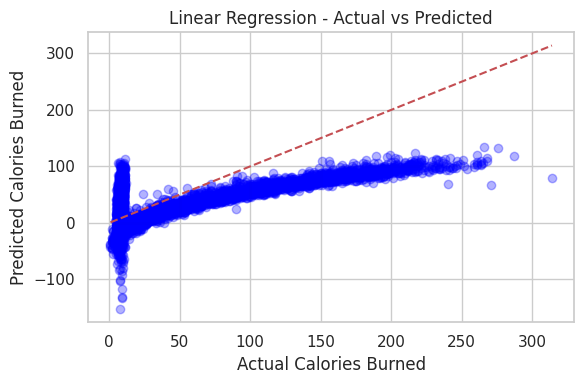

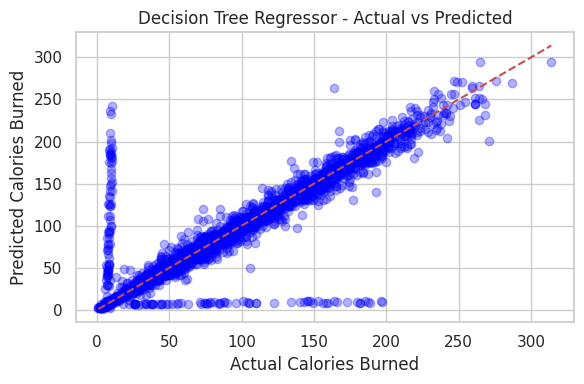

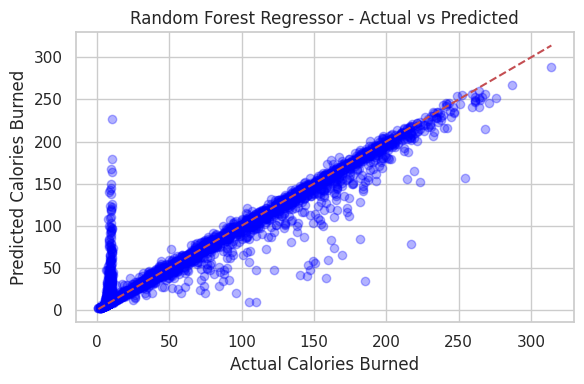

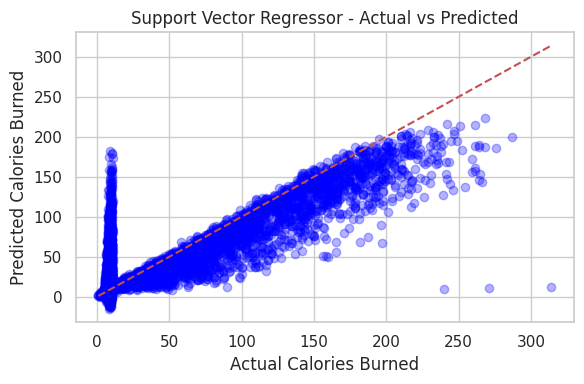

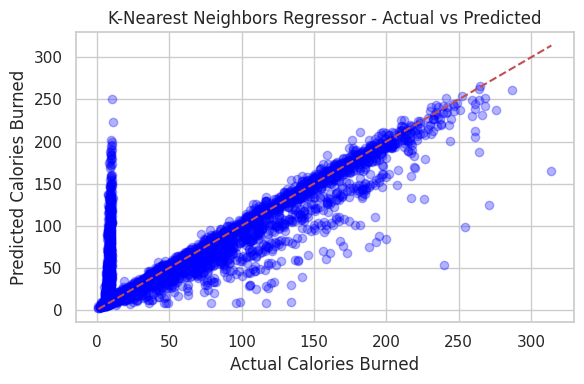

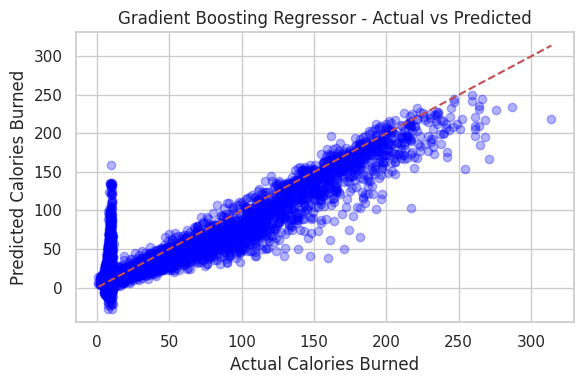

                           Model        MAE          MSE       RMSE  R^2 Score
0              Linear Regression  34.525288  1838.996441  42.883522   0.335216
1        Decision Tree Regressor   3.365589   223.696366  14.956482   0.919135
2        Random Forest Regressor   3.162105   118.531898  10.887236   0.957152
3       Support Vector Regressor  16.497725   785.237156  28.022083   0.716143
4  K-Nearest Neighbors Regressor   9.200078   546.482797  23.376972   0.802451
5    Gradient Boosting Regressor  13.232714   404.322019  20.107760   0.853841


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Updated_calories_augmented_with_health_features.csv'  # Update with the correct path
calories_data = pd.read_csv(file_path)

calories_data = calories_data.drop(columns=['User_ID'], errors='ignore')

for column in calories_data.select_dtypes(include=['object']).columns:
    label_encoder = LabelEncoder()
    calories_data[column] = label_encoder.fit_transform(calories_data[column])

X = calories_data.drop(columns=['Calories'])
y = calories_data['Calories']

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = []

def evaluate_model(model, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2 Score": r2
    })

    # Plot actual vs predicted values
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Calories Burned")
    plt.ylabel("Predicted Calories Burned")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.tight_layout()
    plt.show()

# List of models
models = [
    (LinearRegression(), "Linear Regression"),
    (DecisionTreeRegressor(random_state=42), "Decision Tree Regressor"),
    (RandomForestRegressor(random_state=42), "Random Forest Regressor"),
    (SVR(), "Support Vector Regressor"),
    (KNeighborsRegressor(), "K-Nearest Neighbors Regressor"),
    (GradientBoostingRegressor(random_state=42), "Gradient Boosting Regressor")
]

for model, name in models:
    evaluate_model(model, name)

results_df = pd.DataFrame(results)
print(results_df)



Linear Regression - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0           13.399664
1            114.0           59.814646
2              8.7           39.304193
3             91.0           51.356174
4              9.0           29.052512
5              9.1           33.086280
6              6.8           16.843690
7            186.0           86.460329
8            103.0           61.316737
9              7.5           21.219521


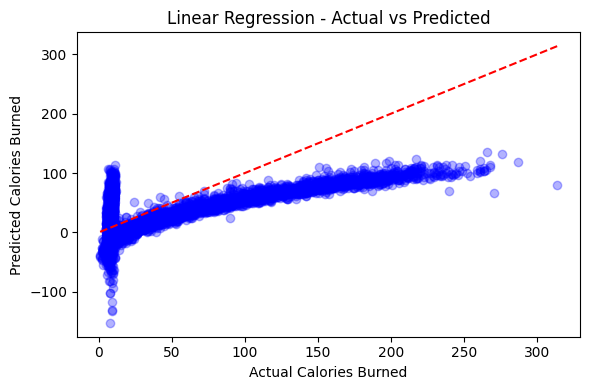


Decision Tree Regressor - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0                 8.0
1            114.0               119.0
2              8.7                 8.7
3             91.0                82.0
4              9.0                 8.6
5              9.1                 9.2
6              6.8                 6.7
7            186.0               176.0
8            103.0               126.0
9              7.5                 7.6


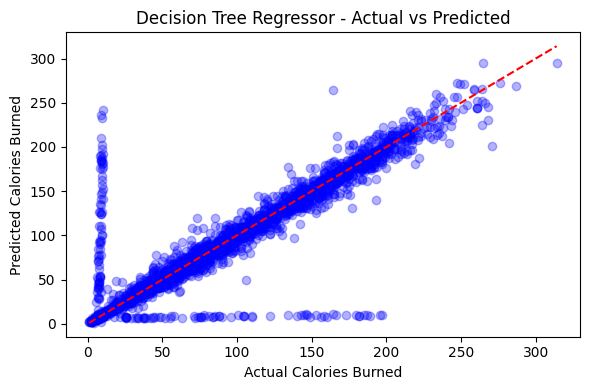


Random Forest Regressor - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0               8.000
1            114.0             110.154
2              8.7               9.383
3             91.0              90.600
4              9.0              10.734
5              9.1               9.116
6              6.8               6.970
7            186.0             188.300
8            103.0             115.470
9              7.5               7.570


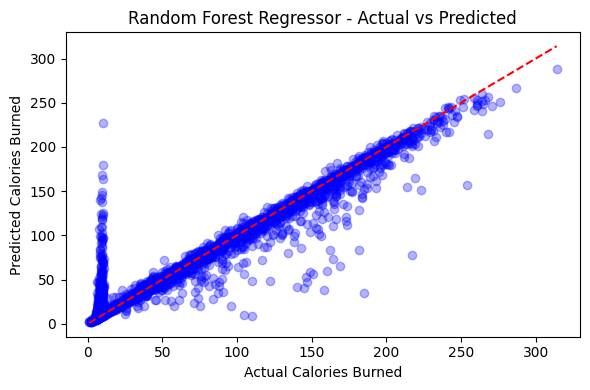


Support Vector Regressor - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0            8.759710
1            114.0           54.631908
2              8.7            3.101801
3             91.0           81.118028
4              9.0           18.036268
5              9.1            4.998790
6              6.8            7.391546
7            186.0          160.913168
8            103.0           71.398978
9              7.5           10.035376


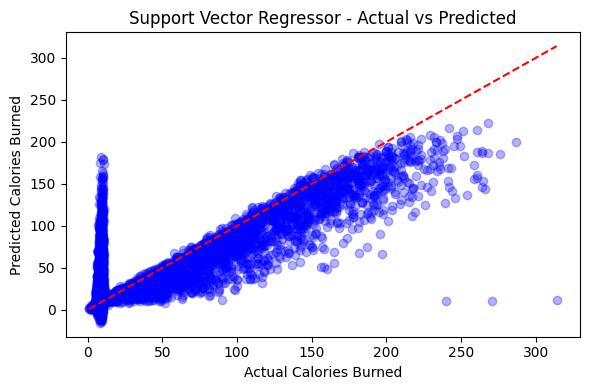


K-Nearest Neighbors Regressor - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0                8.06
1            114.0              119.60
2              8.7                8.60
3             91.0               85.80
4              9.0                8.94
5              9.1                8.78
6              6.8                7.02
7            186.0              179.20
8            103.0              108.00
9              7.5               15.24


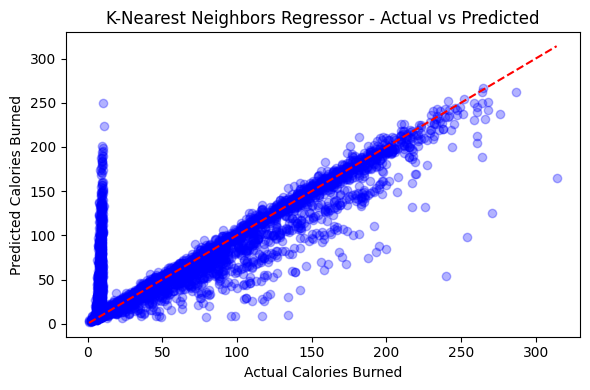


Gradient Boosting Regressor - Actual vs Predicted Calories (first 10 samples):
   Actual Calories  Predicted Calories
0              8.0            4.117178
1            114.0           74.118817
2              8.7           24.138396
3             91.0           69.696628
4              9.0           10.085970
5              9.1            5.056614
6              6.8           15.436667
7            186.0          176.778687
8            103.0          103.071142
9              7.5           14.446281


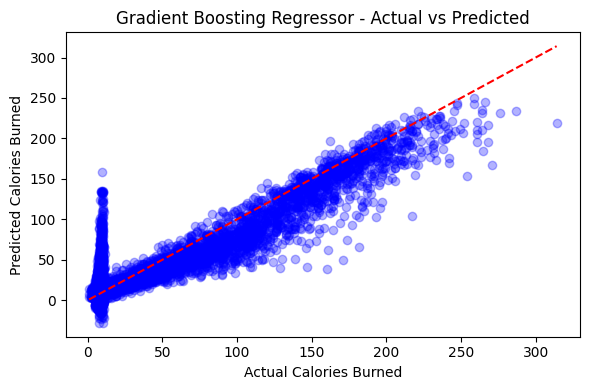

                           Model        MAE          MSE       RMSE  R^2 Score
0              Linear Regression  34.525288  1838.996441  42.883522   0.335216
1        Decision Tree Regressor   3.365589   223.696366  14.956482   0.919135
2        Random Forest Regressor   3.162105   118.531898  10.887236   0.957152
3       Support Vector Regressor  16.497725   785.237156  28.022083   0.716143
4  K-Nearest Neighbors Regressor   9.200078   546.482797  23.376972   0.802451
5    Gradient Boosting Regressor  13.232714   404.322019  20.107760   0.853841


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Updated_calories_augmented_with_health_features.csv'
calories_data = pd.read_csv(file_path)

calories_data = calories_data.drop(columns=['User_ID'], errors='ignore')

for column in calories_data.select_dtypes(include=['object']).columns:
    label_encoder = LabelEncoder()
    calories_data[column] = label_encoder.fit_transform(calories_data[column])


X = calories_data.drop(columns=['Calories'])
y = calories_data['Calories']

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = []

# Function to train and evaluate each model
def evaluate_model(model, model_name):
    # Train the model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2 Score": r2
    })

    comparison_df = pd.DataFrame({
        "Actual Calories": y_test.values,
        "Predicted Calories": y_pred
    })

    print(f"\n{model_name} - Actual vs Predicted Calories (first 10 samples):")
    print(comparison_df.head(10))

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Calories Burned")
    plt.ylabel("Predicted Calories Burned")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.tight_layout()
    plt.show()

models = [
    (LinearRegression(), "Linear Regression"),
    (DecisionTreeRegressor(random_state=42), "Decision Tree Regressor"),
    (RandomForestRegressor(random_state=42), "Random Forest Regressor"),
    (SVR(), "Support Vector Regressor"),
    (KNeighborsRegressor(), "K-Nearest Neighbors Regressor"),
    (GradientBoostingRegressor(random_state=42), "Gradient Boosting Regressor")
]

for model, name in models:
    evaluate_model(model, name)

results_df = pd.DataFrame(results)
print(results_df)
